# 03 — Ablation Exp 1–6 (proposal 3.3.3) → RQ1

In [7]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Six conditions, identical classifier + protocol. TF-IDF sparse + dense → `sparse.hstack` in `features.assemble`. Add LinearSVM (all), MultinomialNB (TF-IDF conditions only — non-negative).

In [8]:
from src import data, features, modeling
clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
y = clean[config.LABEL_COL].values

In [9]:
# Build every block ONCE, then assemble per experiment.
texts = clean['text']
X_tfidf, _ = features.build_tfidf(texts.iloc[splits['train']], texts)
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])
emb = features.build_sbert(texts)   # cached

blocks = {
    'tfidf':       X_tfidf,
    'stylometric': sty_scaled,
    'biber':       bib_scaled,
    'sbert':       emb,
    'length':      clean[['log_token_count']].values,
}

In [10]:
# NB needs non-negative input everywhere -- only exp1 (pure TF-IDF + length,
# both non-negative) qualifies. Scaled dense blocks are mean-centered, so any
# experiment mixing them in would violate MultinomialNB's assumption even if
# it also contains tfidf (proposal 3.2: "TF-IDF-based conditions ... non-negative").
import time

CLASSIFIERS_BY_EXP = {'exp1_tfidf': ['logreg', 'svm', 'nb']}
DEFAULT_CLASSIFIERS = ['logreg', 'svm']

ytr, yval = y[splits['train']], y[splits['val']]
results = {}
t_start = time.time()
for exp_name, which in features.EXPERIMENTS.items():
    X = features.assemble(blocks, which, splits['train'])
    Xtr, Xval = X[splits['train']], X[splits['val']]

    for clf_name in CLASSIFIERS_BY_EXP.get(exp_name, DEFAULT_CLASSIFIERS):
        t0 = time.time()
        results[(exp_name, clf_name)] = modeling.train_and_evaluate(clf_name, Xtr, ytr, Xval, yval)
        elapsed, total = time.time() - t0, time.time() - t_start
        print(f'[{total/60:6.1f} min total] {exp_name:18s} {clf_name:6s} done in {elapsed:6.1f}s '
              f'(macro_f1={results[(exp_name, clf_name)].macro_f1:.3f})')

results_df = pd.DataFrame({
    (exp, clf): {'macro_f1': r.macro_f1, 'weighted_f1': r.weighted_f1, 'accuracy': r.accuracy}
    for (exp, clf), r in results.items()
}).T
results_df.index.names = ['experiment', 'classifier']
results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[  10.6 min total] exp1_tfidf         logreg done in  638.3s (macro_f1=0.745)
[  16.8 min total] exp1_tfidf         svm    done in  369.1s (macro_f1=0.705)
[  16.8 min total] exp1_tfidf         nb     done in    0.4s (macro_f1=0.563)
[  17.3 min total] exp2_style         logreg done in   29.6s (macro_f1=0.366)
[  17.4 min total] exp2_style         svm    done in    4.2s (macro_f1=0.356)
[  29.2 min total] exp3_sbert         logreg done in  712.0s (macro_f1=0.406)
[  32.9 min total] exp3_sbert         svm    done in  217.6s (macro_f1=0.369)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[  45.3 min total] exp4_tfidf_style   logreg done in  742.9s (macro_f1=0.775)
[  55.0 min total] exp4_tfidf_style   svm    done in  584.7s (macro_f1=0.719)
[  61.2 min total] exp5_style_sbert   logreg done in  372.5s (macro_f1=0.472)
[  64.7 min total] exp5_style_sbert   svm    done in  207.2s (macro_f1=0.461)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[ 101.9 min total] exp6_all           logreg done in 2228.7s (macro_f1=0.777)
[ 130.0 min total] exp6_all           svm    done in 1687.4s (macro_f1=0.731)


macro_f1  weighted_f1  accuracy
experiment       classifier                                 
exp1_tfidf       logreg      0.745452     0.745600  0.745287
                 svm         0.705078     0.705233  0.705515
                 nb          0.562501     0.562573  0.565985
exp2_style       logreg      0.366456     0.366267  0.383916
                 svm         0.355795     0.355601  0.399780
exp3_sbert       logreg      0.406035     0.405828  0.414458
                 svm         0.369417     0.369219  0.400000
exp4_tfidf_style logreg      0.775111     0.775234  0.775917
                 svm         0.719434     0.719580  0.719930
exp5_style_sbert logreg      0.472064     0.471956  0.481213
                 svm         0.461272     0.461145  0.488069
exp6_all         logreg      0.776861     0.776983  0.777763
                 svm         0.731163     0.731303  0.731795

Save the results table for the report.

In [11]:
results_df.to_csv(config.ARTIFACTS / 'ablation_results.csv')

PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/ablation_macro_f1.png')

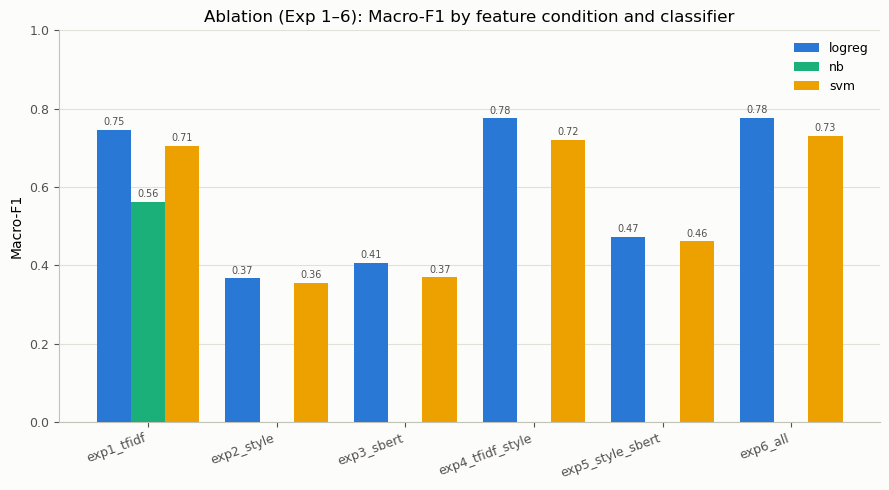

In [12]:
from src import viz

pivot = results_df['macro_f1'].unstack('classifier').reindex(features.EXPERIMENTS.keys())

fig, ax = viz.new_fig(figsize=(9, 5))
n_clf = len(pivot.columns)
width = 0.8 / n_clf
x = np.arange(len(pivot))
for i, clf in enumerate(pivot.columns):
    vals = pivot[clf].values
    valid = ~np.isnan(vals)
    offset = (i - (n_clf - 1) / 2) * width
    bars = ax.bar(x[valid] + offset, vals[valid], width, label=clf,
                   color=viz.CATEGORICAL[i], zorder=3)
    ax.bar_label(bars, fmt='%.2f', fontsize=7, color=viz.INK_SECONDARY, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
ax.set_title('Ablation (Exp 1–6): Macro-F1 by feature condition and classifier')
ax.legend(frameon=False, fontsize=9, title=None)
fig.tight_layout()
save_fig(fig, 'ablation_macro_f1')